# Comparaison des modèles

Objectif : comparer sur le triage le modèle de base, le modèle après SFT et le modèle après SFT puis DPO, avec les mêmes cas et les mêmes scores.

Les réponses sont produites hors du notebook par `scripts/generation.py`, avec vLLM : un fichier par modèle dans `data/generations/`. Le notebook les charge et les compare avec `scripts/evaluation.py`. Un modèle sans fichier de réponses est simplement absent des tableaux.

Les modèles comparés :

- **Toujours maximum** : un classifieur trivial qui répond `maximum` à chaque cas, avec un JSON valide. C'est aussi la classe majoritaire du jeu. C'est le plancher : un modèle utile doit faire mieux.
- **Base (few shot)** : Qwen3-1.7B-Base sans entraînement. Un modèle de base ne sait pas suivre une consigne : il reçoit en plus 3 exemples de triage tirés du train, un par niveau.
- **SFT** : le même modèle avec l'adaptateur LoRA du meilleur checkpoint SFT (`checkpoint-600`).
- **SFT + DPO** : le modèle SFT fusionné, aligné ensuite par DPO sur 5000 paires de préférences UltraMedical (meilleur checkpoint `checkpoint-313`), puis fusionné en un seul modèle (`scripts/merge_model.py`).

**Le jeu utilisé est la validation** (532 cas de triage), avec les labels de Mistral. Ces scores servent à comparer les modèles et à choisir celui qu'on déploie. Le test ne sert qu'une fois, dans la dernière section, pour comparer le modèle retenu aux seuils d'acceptation (go/no-go). On ne revient pas changer de modèle après l'avoir vu.

Les labels de Mistral n'ont pas été validés par des soignants : tous les scores de ce notebook mesurent l'accord avec Mistral, pas une performance clinique.

Décodage : glouton (`temperature` 0), sans pénalité, arrêt au premier retour à la ligne (le JSON d'entraînement tient sur une ligne).

In [1]:
import json
import re
import sys
import warnings
from collections import Counter
from pathlib import Path

sys.path.append("..")
warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from app.triage import SortieTriage, extraire_json, parser_sortie, vers_json
from scripts.evaluation import INVALIDE, NIVEAUX, niveau_lu, niveau_predit, scores_par_langue
from src.visualizer import create_barplot, create_heatmap, save_figure

SPLIT = "validation"
DOSSIER_GENERATIONS = Path("../data/generations")
# nom affiché : nom du fichier de réponses
MODELES = {"Base (few shot)": "base_few_shot", "SFT": "sft", "SFT + DPO": "sft_dpo"}

In [2]:
def charger(split):
    """Les cas de triage d'un split, et les réponses de chaque modèle par id."""
    cas = {}
    with open(f"../data/export/sft/{split}.jsonl", encoding="utf-8") as f:
        for ligne in f:
            exemple = json.loads(ligne)
            if exemple["tache"] == "triage":
                cas[exemple["id"]] = exemple

    # Plancher : toujours maximum, avec un JSON valide
    toujours_maximum = vers_json(SortieTriage(
        urgency_level="maximum", specialty="general_medicine", key_symptoms=["-"],
        red_flags=[], justification="-", recommendation="-",
    ))
    reponses = {"Toujours maximum": {i: toujours_maximum for i in cas}}
    for nom, fichier in MODELES.items():
        chemin = DOSSIER_GENERATIONS / f"{split}_{fichier}.jsonl"
        if chemin.exists():
            with open(chemin, encoding="utf-8") as f:
                reponses[nom] = {g["id"]: g["reponse_modele"] for g in map(json.loads, f)}

    for nom, par_id in reponses.items():
        assert set(par_id) == set(cas), f"{nom} : pas les mêmes cas que le split {split}"
    return cas, reponses


cas, reponses = charger(SPLIT)
ids = list(cas)
attendus = [cas[i]["urgency_level"] for i in ids]
langues = [cas[i]["langue"] for i in ids]
print(f"{len(ids)} cas de triage ({Counter(langues)}), modèles : {list(reponses)}")
print("répartition des labels :", {n: f"{attendus.count(n)} ({100 * attendus.count(n) / len(ids):.0f} %)" for n in NIVEAUX})

532 cas de triage (Counter({'en': 330, 'fr': 202})), modèles : ['Toujours maximum', 'Base (few shot)', 'SFT', 'SFT + DPO']
répartition des labels : {'maximum': '248 (47 %)', 'moderate': '169 (32 %)', 'deferred': '115 (22 %)'}


Près de la moitié des cas de la validation sont des urgences vitales. Une vraie salle d'urgences en voit beaucoup moins. Les scores dépendent de ce mélange : avec moins de `maximum`, chaque fausse alerte pèserait plus lourd face aux vraies urgences, et la précision sur `maximum` serait plus basse qu'ici.

## Comparaison des scores

Pour chaque modèle :

- **JSON valide** : part des réponses qui respectent le schéma (clés, types, valeurs des listes fermées) ;
- **F1 macro** : moyenne des F1 des trois niveaux, la métrique principale ;
- **rappel maximum** : part des urgences vitales reconnues comme telles ;
- **sous triage** : part des patients classés moins urgents qu'ils ne le sont. C'est le risque pour le patient ;
- **sous triage grave** : part des urgences vitales classées `deferred`. C'est l'erreur la plus dangereuse : le patient attend alors qu'il aurait dû passer tout de suite ;
- **sur triage** : part des patients classés plus urgents qu'ils ne le sont. C'est le risque pour le service : des fausses alertes qui encombrent des urgences déjà saturées.

Une réponse invalide compte comme une erreur, et comme un `deferred` pour le sous triage : sans niveau lisible, le patient attend.

In [3]:
def tableau(scores, cle="tous"):
    lignes = []
    for nom, par_langue in scores.items():
        s = par_langue[cle]
        lignes.append({
            "modèle": nom,
            "JSON valide (%)": round(100 * s["json_valide"], 1),
            "F1 macro": round(s["f1_macro"], 2),
            **{f"F1 {niveau}": round(s["f1_par_classe"][niveau], 2) for niveau in NIVEAUX},
            "rappel maximum": round(s["rappel_maximum"], 2),
            "sous triage (%)": round(100 * s["sous_triage"], 1),
            "sous triage grave (%)": round(100 * s["sous_triage_grave"], 1),
            "sur triage (%)": round(100 * s["sur_triage"], 1),
        })
    return pd.DataFrame(lignes).set_index("modèle")


scores = {nom: scores_par_langue(attendus, [par_id[i] for i in ids], langues) for nom, par_id in reponses.items()}
tableau(scores)

,JSON valide (%),F1 macro,F1 maximum,F1 moderate,F1 deferred,rappel maximum,sous triage (%),sous triage grave (%),sur triage (%)
modèle,,,,,,,,,
Toujours maximum,100.0,0.21,0.64,0.00,0.00,1.00,0.0,0.0,53.4
Base (few shot),75.0,0.32,0.48,0.11,0.36,0.32,60.5,56.5,0.9
SFT,99.6,0.74,0.87,0.64,0.70,0.88,10.9,0.8,13.0
SFT + DPO,99.6,0.74,0.87,0.63,0.71,0.90,9.0,0.8,15.0


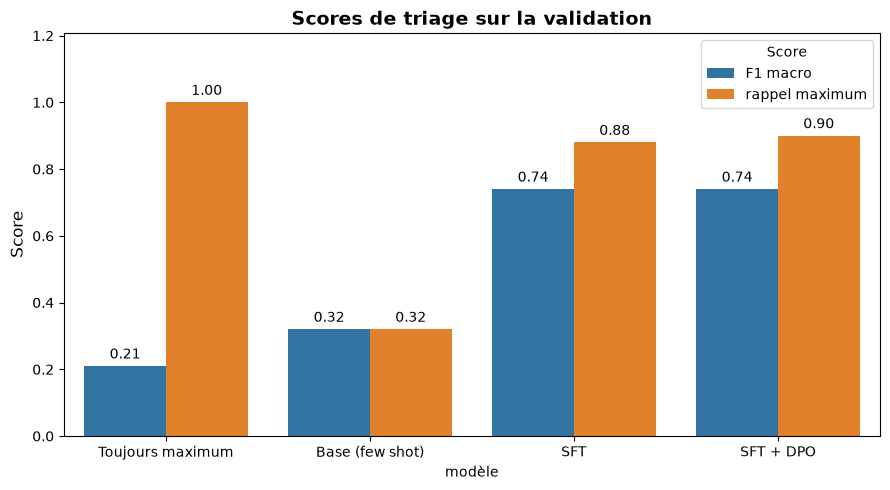

In [4]:
graphe = tableau(scores)[["F1 macro", "rappel maximum"]].reset_index().melt(
    id_vars="modèle", var_name="score", value_name="valeur"
)

fig, ax = plt.subplots(figsize=(9, 5))
create_barplot(
    graphe, ax, x="modèle", y="valeur", hue="score",
    title="Scores de triage sur la validation",
    xlabel="", ylabel="Score", xrotation=0, fmt="{:.2f}",
    show_legend=True, legend_title="Score",
)
plt.tight_layout()
save_figure(fig, "06_comparaison_modeles/scores_par_modele")
plt.show()

Le SFT change complètement le comportement du modèle :

- le format est tenu : 530 réponses valides sur 532, contre 75 % pour la base ;
- le F1 macro passe de 0,32 à 0,74 ;
- il reconnaît 88 % des urgences vitales, contre 32 % pour la base ;
- le sous triage tombe de 61 % à 11 %, et le sous triage grave de 56,5 % à moins de 1 % : 2 urgences vitales classées `deferred` sur 248.

En échange, le SFT sur trie 13 % des patients, contre 1 % pour la base. La base ne sur trie presque jamais parce qu'elle met presque tout en `deferred`, ce qui n'est pas une qualité. Pour l'hôpital, ces 13 % sont des patients vus plus tôt que nécessaire : un coût pour le service, mais pas un danger. Entre les deux erreurs, c'est le bon côté pour pencher.

Le DPO change peu le triage : même F1 macro (0,74), rappel sur `maximum` de 0,90 au lieu de 0,88, sous triage de 9 %. Ce n'était pas son but : ses paires de préférences portent sur des questions médicales générales, pas sur le triage. Le point important est qu'il **n'abîme ni le tri ni le format** : 530 réponses valides sur 532, comme le SFT.

Le plancher « toujours maximum » montre pourquoi le rappel seul ne suffit pas : il trouve toutes les urgences vitales, mais n'aide en rien au tri, et son F1 macro n'est que de 0,21. Les modèles entraînés font mieux que lui sur les F1, mais pas sur le rappel ni sur le sous triage : en classant tout en `maximum`, il ne peut sous trier personne. Le sur triage montre son vrai coût : 53 % des patients seraient envoyés en urgence vitale sans raison, ce qui bloquerait le service.

## Matrices de confusion

Lignes : niveau attendu. Colonnes : niveau prédit, avec une colonne pour les réponses invalides.

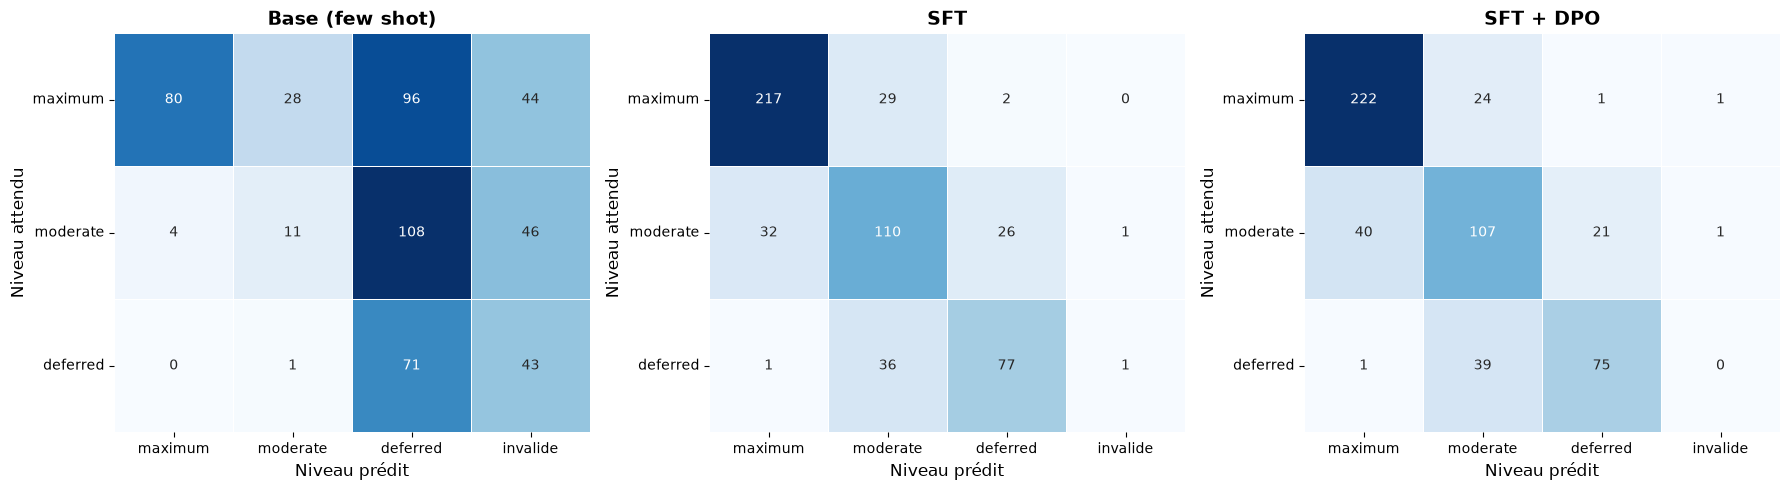

In [5]:
modeles = [nom for nom in scores if nom != "Toujours maximum"]
fig, axes = plt.subplots(1, len(modeles), figsize=(6 * len(modeles), 5))
for ax, nom in zip(np.atleast_1d(axes), modeles):
    matrice = pd.DataFrame(scores[nom]["tous"]["matrice"], index=NIVEAUX, columns=NIVEAUX + [INVALIDE])
    create_heatmap(
        matrice, ax, fmt="d", cmap="Blues", cbar=False, xrotation=0,
        title=nom, xlabel="Niveau prédit", ylabel="Niveau attendu",
    )
plt.tight_layout()
save_figure(fig, "06_comparaison_modeles/matrices_confusion")
plt.show()

La base classe la plupart des cas en `deferred`, y compris une grande partie des urgences vitales : c'est ce qui fait son sous triage. Utilisée telle quelle, elle laisserait attendre plus d'une urgence vitale sur deux.

Les erreurs du SFT restent presque toutes entre niveaux voisins : un `maximum` pris pour un `moderate`, un `moderate` pris pour un `deferred`, ou l'inverse. Il ne classe presque jamais une urgence vitale en `deferred`. Pour le patient, la différence compte : une urgence vitale classée `moderate` est vue dans les heures qui viennent, pas laissée en salle d'attente.

Ses erreurs vers le haut (32 `moderate` classés `maximum`, 36 `deferred` classés `moderate`) sont un peu plus nombreuses que ses erreurs vers le bas. Elles coûtent du temps à l'équipe, sans mettre de patient en danger.

## Résultats par langue

In [6]:
pd.concat({"fr": tableau(scores, "fr"), "en": tableau(scores, "en")})

JSON valide (%)  F1 macro  F1 maximum  F1 moderate  \
   modèle                                                                 
fr Toujours maximum            100.0      0.22        0.66         0.00   
   Base (few shot)              78.7      0.37        0.54         0.22   
   SFT                          99.5      0.73        0.84         0.61   
   SFT + DPO                    99.5      0.71        0.83         0.56   
en Toujours maximum            100.0      0.21        0.62         0.00   
   Base (few shot)              72.7      0.27        0.44         0.00   
   SFT                          99.7      0.75        0.89         0.66   
   SFT + DPO                    99.7      0.75        0.90         0.67   

                     F1 deferred  rappel maximum  sous triage (%)  \
   modèle                                                           
fr Toujours maximum         0.00            1.00              0.0   
   Base (few shot)          0.37            0.38             56.4   
   SFT                      0.72            0.87             10.9   
   SFT + DPO                0.74            0.89              9.4   
en Toujours maximum         0.00            1.00              0.0   
   Base (few shot)          0.36            0.28             63.0   
   SFT                      0.69            0.88             10.9   
   SFT + DPO                0.69            0.90              8.8   

                     sous triage grave (%)  sur triage (%)  
   modèle                                                   
fr Toujours maximum                    0.0            50.5  
   Base (few shot)                    41.0             2.5  
   SFT                                 0.0            13.9  
   SFT + DPO                           1.0            17.3  
en Toujours maximum                    0.0            55.2  
   Base (few shot)                    66.9             0.0  
   SFT                                 1.4            12.4  
   SFT + DPO                           0.7            13.6

Le SFT fait aussi bien en français qu'en anglais. Les cas viennent de sources différentes selon la langue (MediQAl en français, UltraMedical en anglais) : un écart aurait pu venir des sources autant que de la langue.

Le DPO est entièrement en anglais, et on craignait qu'il dégrade le français. Sur le triage, il y a une petite baisse en français : le F1 macro passe de 0,73 à 0,71, surtout à cause de `moderate` (F1 de 0,61 à 0,56), et le sur triage monte de 13,9 % à 17,3 %. Le sous triage en français baisse pourtant un peu (9,4 % contre 10,9 %). En anglais, rien ne se dégrade : F1 macro de 0,75 et rappel sur `maximum` de 0,90. L'écart reste petit, mais il va dans le sens attendu pour un DPO tout en anglais.

## Validité du format

Les réponses invalides n'ont pas toutes la même cause. `parser_sortie` distingue un JSON illisible (`json_invalide`), une structure fausse (`schema_invalide`) et une valeur hors des listes fermées (`valeur_hors_liste`).

In [7]:
statuts = pd.DataFrame({
    nom: Counter(parser_sortie(par_id[i]).statut.value for i in ids)
    for nom, par_id in reponses.items() if nom != "Toujours maximum"
}).fillna(0).astype(int)
statuts

,Base (few shot),SFT,SFT + DPO
valide,399,530,530
valeur_hors_liste,118,1,1
json_invalide,15,1,1


In [8]:
hors_liste = Counter(
    extraire_json(reponses["Base (few shot)"][i]).get("specialty")
    for i in ids
    if parser_sortie(reponses["Base (few shot)"][i]).statut.value == "valeur_hors_liste"
)
print("spécialités hors liste de la base :", hors_liste.most_common(8))

spécialités hors liste de la base : [('pediatrics', 44), ('endocrinology', 15), ('urology', 10), ('hematology', 10), ('dermatology', 7), ('orthopedics', 4), ('ophthalmology', 4), ('otolaryngology', 4)]


La base invente surtout des spécialités qui ne sont pas dans la liste (`pediatrics`, `endocrinology`, `urology`...), alors que son niveau d'urgence est lisible. Pour juger le tri seul, sans pénaliser ces spécialités, le tableau suivant lit le niveau dès qu'il est présent (`niveau_lu`). La colonne « JSON valide » y devient la part de réponses dont le niveau est lisible.

In [9]:
scores_niveau_lu = {
    nom: scores_par_langue(attendus, [par_id[i] for i in ids], langues, lire_niveau=niveau_lu)
    for nom, par_id in reponses.items() if nom != "Toujours maximum"
}
tableau(scores_niveau_lu)

,JSON valide (%),F1 macro,F1 maximum,F1 moderate,F1 deferred,rappel maximum,sous triage (%),sous triage grave (%),sur triage (%)
modèle,,,,,,,,,
Base (few shot),97.2,0.38,0.52,0.16,0.45,0.35,57.7,52.4,1.1
SFT,99.8,0.74,0.87,0.64,0.70,0.88,10.7,0.8,13.0
SFT + DPO,99.8,0.74,0.87,0.64,0.71,0.90,8.8,0.8,15.0


Même jugée sur le niveau seul, la base reste loin du SFT : F1 macro de 0,38 et rappel sur `maximum` de 0,35. Son problème n'est pas le format, c'est le tri : elle classe en `deferred` plus de la moitié des cas. Le classement des modèles ne change pas.

Les scores officiels restent ceux du premier tableau : en production, une réponse avec une spécialité inconnue ne peut pas être utilisée telle quelle.

## Les urgences vitales ratées par le SFT

Le sous triage d'une urgence vitale est l'erreur la plus grave. Je regarde quelques cas `maximum` que le SFT a classés autrement, avec la justification de Mistral (le label) et celle du SFT.

In [10]:
rates = [i for i in ids if cas[i]["urgency_level"] == "maximum" and niveau_predit(reponses["SFT"][i]) != "maximum"]
print(f"{len(rates)} urgences vitales ratées sur {attendus.count('maximum')}")

for i in rates[:6]:
    sortie_sft = extraire_json(reponses["SFT"][i]) or {}
    print(f"\n===== {i} ({cas[i]['langue']}) : prédit {niveau_predit(reponses['SFT'][i])}")
    print("cas     :", cas[i]["instruction"][:400].replace("\n", " "), "...")
    print("Mistral :", json.loads(cas[i]["reponse"])["justification"])
    print("SFT     :", sortie_sft.get("justification"))

31 urgences vitales ratées sur 248

===== mediqal_cas_70 (fr) : prédit moderate
cas     : Cet enfant de 5 ans, émigré, n'ayant reçu aucune vaccination, présente une toux quinteuse, diurne et nocturne, depuis une huitaine de jours. Les quintes déclenchent parfois des vomissements. Il existe des douleurs abdominales et la température est normale. Comme l'examen montre quelques râles au niveau des bases, le médecin a prescrit un sirop antitussif et des injections journalières de Pénicilli ...
Mistral : La toux quinteuse persistante depuis plus d'une semaine chez un enfant non vacciné est fortement suggestive de coqueluche, une infection potentiellement grave à cet âge. L'absence de réponse aux antibiotiques prescrits et le terrain non immunisé justifient une prise en charge urgente pour prévenir les complications respiratoires ou neurologiques.
SFT     : Le patient présente une toux quinteuse avec vomissements et douleurs abdominales depuis 8 jours, sans signe de détresse respiratoire ou 

Ces erreurs sont de deux sortes.

- **De vraies urgences ratées.** Par exemple, une hématurie avec caillots chez un patient sous anticoagulant, avec une hémoglobine à 46 g/l : le SFT relève l'anémie mais conclut à une urgence modérée. Ou des syncopes à l'effort sur un rétrécissement aortique serré. Ce sont les cas qui comptent pour la sécurité.
- **Des labels discutables.** Plusieurs `maximum` de Mistral reposent sur des résultats d'examens (cortisolémie, sérologie de toxoplasmose) ou sur une hypertension sans signe de souffrance aiguë. Le protocole demande pourtant de ne tenir compte des examens que s'ils montrent un danger immédiat. Ici, le `moderate` du SFT se défend.

Une partie des « erreurs » du modèle sont donc des erreurs du label. Je ne suis pas médecin et les labels n'ont pas été relus par des soignants : je ne peux pas trancher ces cas. C'est une limite du POC. Le rappel sur `maximum` mesure l'accord avec Mistral, et le vrai rappel clinique peut être un peu meilleur ou un peu moins bon.

## Langue des réponses

La consigne demande la justification dans la langue du cas. Pour les cas anglais, les labels d'entraînement ont été traduits (notebook 04). Je vérifie que le modèle a appris à répondre dans la bonne langue, avec un test simple sur les mots outils les plus fréquents.

In [11]:
MOTS_FR = {"le", "la", "les", "des", "est", "une", "un", "dans", "pour", "avec", "du", "au", "et", "de"}
MOTS_EN = {"the", "is", "with", "for", "and", "of", "in", "to", "an", "are", "this"}


def langue_texte(texte):
    mots = re.findall(r"[a-zàâçéèêëîïôûùüÿœ']+", texte.lower())
    return "fr" if sum(m in MOTS_FR for m in mots) > sum(m in MOTS_EN for m in mots) else "en"


lignes = []
for nom in modeles:
    for i in ids:
        sortie = extraire_json(reponses[nom][i])
        if sortie and isinstance(sortie.get("justification"), str):
            lignes.append({"modèle": nom, "langue du cas": cas[i]["langue"], "langue de la réponse": langue_texte(sortie["justification"])})
langue_df = pd.DataFrame(lignes)
pd.crosstab([langue_df["modèle"], langue_df["langue du cas"]], langue_df["langue de la réponse"])

langue de la réponse            en   fr
modèle          langue du cas          
Base (few shot) en             325    0
                fr               6  186
SFT             en             330    0
                fr               0  201
SFT + DPO       en             330    0
                fr               0  201

Le SFT répond dans la langue du cas : en anglais pour les 330 cas anglais, en français pour les 201 cas français qui ont une justification lisible (pour le 202e, son JSON est illisible). Le SFT + DPO aussi. Sans la traduction des labels, il aurait appris à répondre en français aux cas anglais.

## Ce que change le DPO

Les scores bougent peu. Je regarde combien de niveaux changent entre le SFT et le SFT + DPO, et si les réponses s'allongent : c'est l'effet connu d'un DPO sur des paires où la réponse préférée est souvent la plus longue. Les paires d'entraînement ont été tirées équilibrées sur la longueur pour l'éviter.

In [12]:
changes = sum(niveau_predit(reponses["SFT"][i]) != niveau_predit(reponses["SFT + DPO"][i]) for i in ids)
print(f"niveaux différents entre SFT et SFT + DPO : {changes} sur {len(ids)}")

lignes = []
for nom in ["SFT", "SFT + DPO"]:
    sorties = [extraire_json(reponses[nom][i]) or {} for i in ids]
    lignes.append({
        "modèle": nom,
        "longueur de la réponse": round(np.mean([len(reponses[nom][i]) for i in ids])),
        "longueur de la justification": round(np.mean([len(s.get("justification", "")) for s in sorties])),
        "symptômes par cas": round(np.mean([len(s.get("key_symptoms", [])) for s in sorties]), 2),
        "signes d'alerte par cas": round(np.mean([len(s.get("red_flags", [])) for s in sorties]), 2),
    })
pd.DataFrame(lignes).set_index("modèle")

niveaux différents entre SFT et SFT + DPO : 25 sur 532


,longueur de la réponse,longueur de la justification,symptômes par cas,signes d'alerte par cas
modèle,,,,
SFT,796,344,4.61,2.14
SFT + DPO,830,361,4.70,2.27


Le DPO ne change le niveau que de 25 cas sur 532. Il pousse un peu vers le haut : le sous triage passe de 10,9 % à 9 %, le sur triage de 13 % à 15 %, et le sous triage grave reste à 2 urgences vitales sur 248. Les réponses s'allongent à peine : la justification passe de 344 à 361 caractères en moyenne, soit environ 5 %. L'équilibrage sur la longueur a fait son travail : le DPO n'a pas appris à être bavard.

Un premier DPO sur 2000 paires changeait encore moins de choses : 13 niveaux sur 532, F1 macro de 0,73, rappel sur `maximum` de 0,88. Passer à 5000 paires améliore la loss de validation du DPO (0,364 contre 0,434), mais l'effet sur le triage reste dans le bruit.

Pour l'hôpital, c'est ce qui compte : le DPO n'apporte pas de régression. Il ne fait rater aucune urgence vitale de plus, il ne casse pas le format que lit l'application, et l'infirmier n'a pas plus de texte à lire. Son seul coût est un peu plus de fausses alertes, surtout en français. On peut donc déployer le modèle SFT + DPO à la place du SFT sans risque pour le triage.

## Synthèse

Sur la validation (532 cas, labels de Mistral) :

| Modèle | JSON valide | F1 macro | Rappel maximum | Sous triage | Sous triage grave | Sur triage |
|---|---|---|---|---|---|---|
| Toujours maximum | 100 % | 0,21 | 1,00 | 0 % | 0 % | 53 % |
| Base (few shot) | 75 % | 0,32 | 0,32 | 61 % | 56,5 % | 1 % |
| SFT | 99,6 % | 0,74 | 0,88 | 11 % | 0,8 % | 13 % |
| SFT + DPO | 99,6 % | 0,74 | 0,90 | 9 % | 0,8 % | 15 % |

Le SFT apprend à la fois le format et le tri. Il tient le JSON, répond dans la langue du cas, et fait aussi bien en français qu'en anglais. Ses erreurs restent entre niveaux voisins.

Le DPO, entraîné sur des questions médicales générales en anglais, change peu le triage : il ne modifie le niveau que de 25 cas et pousse un peu vers le haut (moins de sous triage, plus de sur triage). Il garde le format et la langue, et n'allonge presque pas les réponses. Le français baisse un peu (F1 macro de 0,73 à 0,71), dans le bruit mais à surveiller. Il n'améliore pas vraiment le triage, mais il ne l'abîme pas. Pour qu'il vise directement les urgences ratées, il faudrait l'entraîner sur des paires de triage, où la réponse préférée donne le bon niveau et la réponse rejetée sous trie le patient. C'est une piste pour la suite.

Ce que ça veut dire pour le CHSA : sur 100 urgences vitales, le modèle final (SFT + DPO) en reconnaît 90. Les 10 autres sont presque toutes classées `moderate`, donc vues dans les heures qui viennent, et moins d'une est laissée en attente. Le modèle ne peut donc pas trier seul : c'est une aide pour l'infirmier d'accueil, qui garde la décision. En échange, il sur trie environ 15 % des patients, un coût en temps pour l'équipe plutôt qu'un risque.

Points à suivre :

- 10 % des urgences vitales sont ratées, dont une partie avec un label discutable. Sans relecture par des soignants, on ne sait pas combien sont de vraies erreurs.
- Le rappel sur `maximum` est à 0,90, pile au seuil d'acceptation : le verdict se joue sur le test, dans la section suivante.

## Évaluation finale sur le test

Le modèle retenu est le SFT + DPO, choisi sur la validation. Le test (531 cas de triage) ne sert qu'ici, une seule fois, pour le comparer aux seuils d'acceptation. Les seuils ont été fixés le 2026-10-04, avant de générer les réponses sur le test. Ils se justifient par le risque clinique : très exigeants sur le sous triage, plus tolérants sur le sur triage.

| Métrique | Seuil | Pourquoi |
|---|---|---|
| JSON valide | ≥ 99 % | une réponse illisible bloque le patient |
| Rappel sur `maximum` | ≥ 0,90 | rater au plus 1 urgence vitale sur 10 |
| Sous triage grave | ≤ 1 % | c'est l'erreur qui peut tuer |
| Sous triage | ≤ 10 % | ça reste une erreur dangereuse |
| Sur triage | ≤ 25 % | ça coûte du temps, pas de vie |
| Langue respectée | ≥ 98 % | un soignant doit pouvoir lire la réponse |
| F1 macro | ≥ 0,70 | indicatif, ne suffit pas à lui seul |

Les labels sont toujours ceux de Mistral, non validés par des soignants.

In [13]:
cas_test, reponses_test = charger("test")
ids_test = list(cas_test)
attendus_test = [cas_test[i]["urgency_level"] for i in ids_test]
langues_test = [cas_test[i]["langue"] for i in ids_test]
print(f"{len(ids_test)} cas de triage ({Counter(langues_test)}), modèles : {list(reponses_test)}")
print("répartition des labels :", {n: f"{attendus_test.count(n)} ({100 * attendus_test.count(n) / len(ids_test):.0f} %)" for n in NIVEAUX})

scores_test = {
    nom: scores_par_langue(attendus_test, [par_id[i] for i in ids_test], langues_test)
    for nom, par_id in reponses_test.items()
}
tableau(scores_test)

531 cas de triage (Counter({'en': 329, 'fr': 202})), modèles : ['Toujours maximum', 'Base (few shot)', 'SFT', 'SFT + DPO']
répartition des labels : {'maximum': '248 (47 %)', 'moderate': '169 (32 %)', 'deferred': '114 (21 %)'}


,JSON valide (%),F1 macro,F1 maximum,F1 moderate,F1 deferred,rappel maximum,sous triage (%),sous triage grave (%),sur triage (%)
modèle,,,,,,,,,
Toujours maximum,100.0,0.21,0.64,0.00,0.00,1.00,0.0,0.0,53.3
Base (few shot),70.2,0.30,0.47,0.14,0.30,0.31,60.3,61.3,0.9
SFT,100.0,0.78,0.89,0.68,0.78,0.91,8.5,0.0,11.5
SFT + DPO,99.8,0.77,0.89,0.68,0.75,0.94,7.2,0.0,13.2


In [14]:
pd.concat({"fr": tableau(scores_test, "fr"), "en": tableau(scores_test, "en")})

JSON valide (%)  F1 macro  F1 maximum  F1 moderate  \
   modèle                                                                 
fr Toujours maximum            100.0      0.22        0.66         0.00   
   Base (few shot)              68.3      0.38        0.60         0.25   
   SFT                         100.0      0.80        0.89         0.72   
   SFT + DPO                    99.5      0.80        0.91         0.72   
en Toujours maximum            100.0      0.21        0.62         0.00   
   Base (few shot)              71.4      0.24        0.37         0.05   
   SFT                         100.0      0.77        0.88         0.66   
   SFT + DPO                   100.0      0.76        0.87         0.65   

                     F1 deferred  rappel maximum  sous triage (%)  \
   modèle                                                           
fr Toujours maximum         0.00            1.00              0.0   
   Base (few shot)          0.30            0.44             54.0   
   SFT                      0.79            0.93              5.9   
   SFT + DPO                0.77            0.96              5.0   
en Toujours maximum         0.00            1.00              0.0   
   Base (few shot)          0.29            0.23             64.1   
   SFT                      0.78            0.89             10.0   
   SFT + DPO                0.74            0.92              8.5   

                     sous triage grave (%)  sur triage (%)  
   modèle                                                   
fr Toujours maximum                    0.0            50.5  
   Base (few shot)                    47.0             1.5  
   SFT                                 0.0            11.9  
   SFT + DPO                           0.0            12.4  
en Toujours maximum                    0.0            55.0  
   Base (few shot)                    70.9             0.6  
   SFT                                 0.0            11.2  
   SFT + DPO                           0.0            13.7

In [15]:
def langue_respectee(reponse, langue):
    sortie = extraire_json(reponse)
    return bool(sortie) and isinstance(sortie.get("justification"), str) and langue_texte(sortie["justification"]) == langue


final = scores_test["SFT + DPO"]["tous"]
langue_ok = sum(langue_respectee(reponses_test["SFT + DPO"][i], cas_test[i]["langue"]) for i in ids_test)

# métrique, valeur, seuil, True si la valeur doit être au moins égale au seuil
seuils = [
    ("JSON valide (%)", 100 * final["json_valide"], 99, True),
    ("rappel maximum", final["rappel_maximum"], 0.90, True),
    ("sous triage grave (%)", 100 * final["sous_triage_grave"], 1, False),
    ("sous triage (%)", 100 * final["sous_triage"], 10, False),
    ("sur triage (%)", 100 * final["sur_triage"], 25, False),
    ("langue respectée (%)", 100 * langue_ok / len(ids_test), 98, True),
    ("F1 macro (indicatif)", final["f1_macro"], 0.70, True),
]
pd.DataFrame([
    {
        "métrique": nom,
        "seuil": f"{'≥' if minimum else '≤'} {seuil}",
        "valeur": round(valeur, 2),
        "passe": valeur >= seuil if minimum else valeur <= seuil,
    }
    for nom, valeur, seuil, minimum in seuils
]).set_index("métrique")

,seuil,valeur,passe
métrique,,,
JSON valide (%),≥ 99,99.81,True
rappel maximum,≥ 0.9,0.94,True
sous triage grave (%),≤ 1,0.00,True
sous triage (%),≤ 10,7.16,True
sur triage (%),≤ 25,13.18,True
langue respectée (%),≥ 98,99.81,True
F1 macro (indicatif),≥ 0.7,0.77,True


Avec 248 urgences vitales, les chiffres ont une marge d'erreur. Pour le rappel, j'utilise l'intervalle à 95 % de l'approximation normale. Pour le sous triage grave, aucun cas n'est observé : la règle de trois donne une borne haute à 95 % de 3 divisé par le nombre de cas.

In [16]:
n_maximum = attendus_test.count("maximum")
rappel = final["rappel_maximum"]
marge = 1.96 * np.sqrt(rappel * (1 - rappel) / n_maximum)
graves = round(final["sous_triage_grave"] * n_maximum)
print(f"rappel maximum : {rappel:.2f}, intervalle à 95 % [{rappel - marge:.2f} ; {rappel + marge:.2f}] sur {n_maximum} urgences vitales")
print(f"sous triage grave : {graves} sur {n_maximum}, borne haute à 95 % {100 * 3 / n_maximum:.1f} % (règle de trois, valable avec 0 cas)")

rappel maximum : 0.94, intervalle à 95 % [0.90 ; 0.97] sur 248 urgences vitales
sous triage grave : 0 sur 248, borne haute à 95 % 1.2 % (règle de trois, valable avec 0 cas)


### Verdict

Sur le test, le SFT + DPO passe tous les seuils : 99,8 % de JSON valide, rappel sur `maximum` de 0,94, aucune urgence vitale classée `deferred`, 7,2 % de sous triage, 13,2 % de sur triage, 99,8 % de réponses dans la langue du cas, F1 macro de 0,77. Le SFT seul les passe aussi, avec un rappel sur `maximum` de 0,91. Les deux restent très loin de la base (F1 macro de 0,30, rappel de 0,31) et du plancher « toujours maximum » (53 % de sur triage).

Le test fait un peu mieux que la validation (rappel de 0,94 contre 0,90, F1 macro de 0,77 contre 0,74). Ce n'est pas une fuite : le contrôle de fuite entre splits ne trouve aucun cas commun. C'est la variation normale entre deux jeux d'environ 530 cas. Le rappel sur `maximum` a un intervalle à 95 % de 0,90 à 0,97 : il vaut mieux annoncer cette fourchette qu'un chiffre exact. Le bas de la fourchette touche le seuil.

Aucun sous triage grave sur 248 urgences vitales ne prouve pas que le vrai taux est sous 1 % : il peut aller jusqu'à environ 1,2 %. Il faudrait plus de cas pour le garantir.

Le français ne se dégrade pas après le DPO sur le test (F1 macro de 0,80 avant et après) : la petite baisse vue sur la validation était du bruit.

**Décision : go pour une étude pilote, pas pour la production.** Le modèle est une aide pour l'infirmier d'accueil, qui garde la décision. Avant toute mise en production, il faut :

- faire relire le test par des urgentistes, car les scores mesurent ici l'accord avec Mistral, pas une performance clinique ;
- évaluer sur plus d'urgences vitales, pour garantir un sous triage grave sous 1 % ;
- tester le modèle sur des descriptions écrites par de vrais patients, et non par des médecins.